# 04 Time Series Forecasting

Build a daily temperature series, train forecasting models, compare metrics, and save model artifacts.


In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = next(
    (
        candidate
        for candidate in (NOTEBOOK_DIR, *NOTEBOOK_DIR.parents)
        if (candidate / "src").exists() and (candidate / "data").exists()
    ),
    NOTEBOOK_DIR,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "GlobalWeatherRepository.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from statsmodels.tsa.arima.model import ARIMA

from src.eval import evaluate_forecast, summarize_results
from src.features import build_daily_temperature_series
from src.preprocessing import load_processed_data
from src.visualize import save_figure


In [3]:
anomaly_free_path = PROCESSED_DIR / "weather_without_anomalies.csv"
clean_path = PROCESSED_DIR / "clean_weather_data.csv"
source_path = anomaly_free_path if anomaly_free_path.exists() else clean_path

df = load_processed_data(source_path)
ts = build_daily_temperature_series(df)

print(f"Loaded source data from: {source_path}")
print(f"Daily series length: {len(ts)}")
print(f"Series range: {ts.index.min()} to {ts.index.max()}")
display(ts.head())


Loaded source data from: d:\Projects 2025\weather-forecasting-eda-ml\data\processed\weather_without_anomalies.csv
Daily series length: 708
Series range: 2024-05-16 00:00:00 to 2026-04-24 00:00:00


last_updated
2024-05-16    23.773481
2024-05-17    24.419429
2024-05-18    25.416583
2024-05-19    25.365775
2024-05-20    25.539674
Name: temperature_celsius, dtype: float64

In [4]:
if len(ts) < 60:
    raise ValueError("The daily time series is too short for the planned forecasting workflow.")

train_size = int(len(ts) * 0.8)
train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

arima_model = ARIMA(train, order=(5, 1, 2))
arima_fit = arima_model.fit()
arima_forecast = pd.Series(arima_fit.forecast(steps=len(test)).to_numpy(), index=test.index)

forecast_results = {"arima": evaluate_forecast(test, arima_forecast)}


D:\Projects 2025\weather-forecasting-eda-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Projects 2025\weather-forecasting-eda-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Projects 2025\weather-forecasting-eda-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


D:\Projects 2025\weather-forecasting-eda-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\Projects 2025\weather-forecasting-eda-ml\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [5]:
prophet_model = None
prophet_forecast = None

try:
    from prophet import Prophet

    prophet_train = train.reset_index()
    prophet_train.columns = ["ds", "y"]

    prophet_model = Prophet()
    prophet_model.fit(prophet_train)

    future = prophet_model.make_future_dataframe(periods=len(test), freq="D")
    forecast_frame = prophet_model.predict(future)
    prophet_forecast = forecast_frame.set_index("ds").loc[test.index, "yhat"]
    forecast_results["prophet"] = evaluate_forecast(test, prophet_forecast)
except Exception as exc:
    print(f"Prophet training skipped: {exc}")


23:44:04 - cmdstanpy - INFO - Chain [1] start processing


23:44:05 - cmdstanpy - INFO - Chain [1] done processing


,mae,rmse,mape,r2
arima,1.202027,1.738967,8.921228,-0.021536
prophet,4.390098,5.770768,25.985274,-10.249628


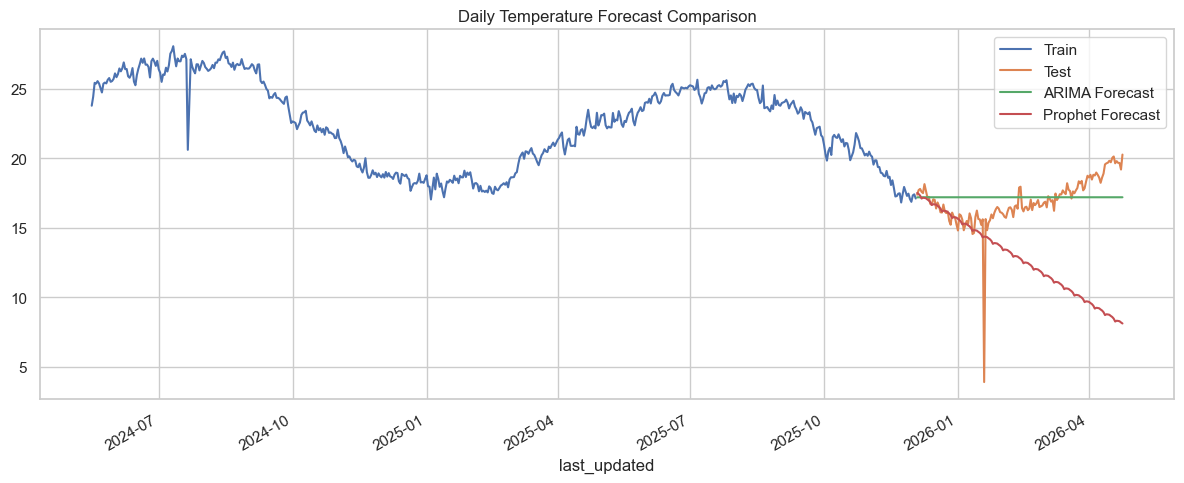

In [6]:
results_df = summarize_results(forecast_results)
display(results_df)

fig, ax = plt.subplots(figsize=(12, 5))
train.plot(ax=ax, label="Train")
test.plot(ax=ax, label="Test")
arima_forecast.plot(ax=ax, label="ARIMA Forecast")
if prophet_forecast is not None:
    prophet_forecast.plot(ax=ax, label="Prophet Forecast")
ax.set_title("Daily Temperature Forecast Comparison")
ax.legend()
plt.tight_layout()
display(fig)
save_figure(fig, FIGURES_DIR / "forecast_comparison.png")
plt.close(fig)


In [7]:
forecast_metrics_path = PROJECT_ROOT / "reports" / "forecast_metrics.csv"
results_df.to_csv(forecast_metrics_path)
arima_model_path = MODELS_DIR / "arima_temperature_model.joblib"
joblib.dump(arima_fit, arima_model_path)
print(f"Saved ARIMA model to: {arima_model_path}")

if prophet_model is not None:
    prophet_model_path = MODELS_DIR / "prophet_temperature_model.joblib"
    joblib.dump(prophet_model, prophet_model_path)
    print(f"Saved Prophet model to: {prophet_model_path}")

print(f"Saved forecast metrics to: {forecast_metrics_path}")


Saved ARIMA model to: d:\Projects 2025\weather-forecasting-eda-ml\models\arima_temperature_model.joblib
Saved Prophet model to: d:\Projects 2025\weather-forecasting-eda-ml\models\prophet_temperature_model.joblib
Saved forecast metrics to: d:\Projects 2025\weather-forecasting-eda-ml\reports\forecast_metrics.csv
